In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('images', exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [3]:
campaigns = pd.read_csv('data/campaigns.csv')
platforms = pd.read_csv('data/platforms.csv')
campaign_types = pd.read_csv('data/campaign_types.csv')

print("Data loaded.")

Data loaded.


In [4]:
# Create a copy for KPI calculations
df = campaigns.copy()

# Calculate KPIs
df['CTR'] = df['Clicks'] / df['Impressions']
df['CPC'] = df['Cost'] / df['Clicks'].replace(0, np.nan)
df['CPM'] = (df['Cost'] / df['Impressions']) * 1000
df['CVR'] = df['Conversions'] / df['Clicks'].replace(0, np.nan)
df['CPA'] = df['Cost'] / df['Conversions'].replace(0, np.nan)
df['ROAS'] = df['Revenue'] / df['Cost'].replace(0, np.nan)
df['RevenuePerClick'] = df['Revenue'] / df['Clicks'].replace(0, np.nan)

print("KPIs calculated.")
print("-" * 40)

kpi_cols = ['CTR', 'CPC', 'CPM', 'CVR', 'CPA', 'ROAS', 'RevenuePerClick']
print(df[kpi_cols].describe().round(4))

KPIs calculated.
----------------------------------------
              CTR         CPC         CPM         CVR         CPA        ROAS  \
count  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000   
mean       0.0182      2.2938     38.9225      0.0517     47.1018      2.7847   
std        0.0085      1.3189     23.0426      0.0121     30.7945      1.7880   
min        0.0036      0.6439      4.6992      0.0079      9.7966      0.1142   
25%        0.0115      1.2736     19.9642      0.0428     25.3542      2.5681   
50%        0.0170      1.8213     36.3350      0.0525     37.6226      2.8384   
75%        0.0236      2.8680     50.9172      0.0607     59.0909      3.0713   
max        0.0526      7.2724    164.1812      0.0882    291.2170     33.2682   

       RevenuePerClick  
count       10000.0000  
mean            6.3006  
std             5.4166  
min             0.1212  
25%             3.1493  
50%             5.0856  
75%             8.3358  
max         

In [5]:
print("Top 10 Campaigns by ROI")
print("-" * 40)
top_roi = df.nlargest(10, 'ROI')[['CampaignID', 'PlatformID', 'CampaignTypeID', 
                                   'ROI', 'CTR', 'CPC', 'CVR', 'CPA', 'ROAS']].round(4)
print(top_roi.to_string(index=False))

Top 10 Campaigns by ROI
----------------------------------------
CampaignID  PlatformID  CampaignTypeID    ROI    CTR    CPC    CVR     CPA    ROAS
 CAM000105           2               3 1500.0 0.0275 1.6118 0.0622 25.8980 23.9211
 CAM000134           6               1 1500.0 0.0170 0.9393 0.0562 16.7199 26.9392
 CAM000212           2               2 1500.0 0.0328 1.4486 0.0565 25.6158 17.8975
 CAM000282           5               3 1500.0 0.0176 1.1101 0.0584 19.0222 30.1964
 CAM000409           2               1 1500.0 0.0351 1.1188 0.0646 17.3267 28.1078
 CAM000485           4               5 1500.0 0.0153 3.0936 0.0381 81.2991 16.1675
 CAM000700           1               3 1500.0 0.0289 3.0102 0.0468 64.3714 30.7480
 CAM000920           2               3 1500.0 0.0325 1.5401 0.0632 24.3572 16.5628
 CAM000944           2               6 1500.0 0.0164 1.4076 0.0306 45.9644 26.9568
 CAM001234           5               3 1500.0 0.0161 1.2686 0.0572 22.1819 22.0994


In [6]:
# Merge with platforms
df_platform = df.merge(platforms, on='PlatformID')

# Aggregate by platform
platform_kpi = df_platform.groupby('PlatformName').agg({
    'CampaignID': 'count',
    'CTR': 'mean',
    'CPC': 'mean',
    'CPM': 'mean',
    'CVR': 'mean',
    'CPA': 'mean',
    'ROAS': 'mean',
    'ROI': 'mean',
    'Revenue': 'sum',
    'Cost': 'sum'
}).round(4)

platform_kpi.columns = ['Campaigns', 'CTR', 'CPC', 'CPM', 'CVR', 'CPA', 'ROAS', 'ROI', 'Revenue', 'Cost']
platform_kpi = platform_kpi.sort_values('ROI', ascending=False)

print("Platform KPI Summary")
print("-" * 40)
print(platform_kpi.to_string())

Platform KPI Summary
----------------------------------------
              Campaigns     CTR     CPC      CPM     CVR       CPA    ROAS       ROI       Revenue          Cost
PlatformName                                                                                                    
Google Ads         1374  0.0301  2.5070  75.5736  0.0544   48.7883  3.0994  206.4760  6.656940e+08  2.146929e+08
TikTok             1465  0.0250  1.5101  37.8072  0.0525   30.6226  2.9575  192.4833  2.808918e+08  9.584835e+07
Instagram          1431  0.0199  1.8167  36.1058  0.0511   37.9002  2.8733  184.4203  2.505399e+08  8.877112e+07
YouTube            1430  0.0182  3.0039  54.5933  0.0511   62.8941  2.7975  177.5888  2.811175e+08  9.957317e+07
Facebook           1420  0.0150  1.2110  18.1450  0.0500   25.8905  2.7042  167.2207  1.102182e+08  4.088968e+07
X (Twitter)        1419  0.0120  1.0062  12.1203  0.0501   21.6214  2.6008  157.5907  5.062319e+07  1.987271e+07
LinkedIn           1461  0.0079  4

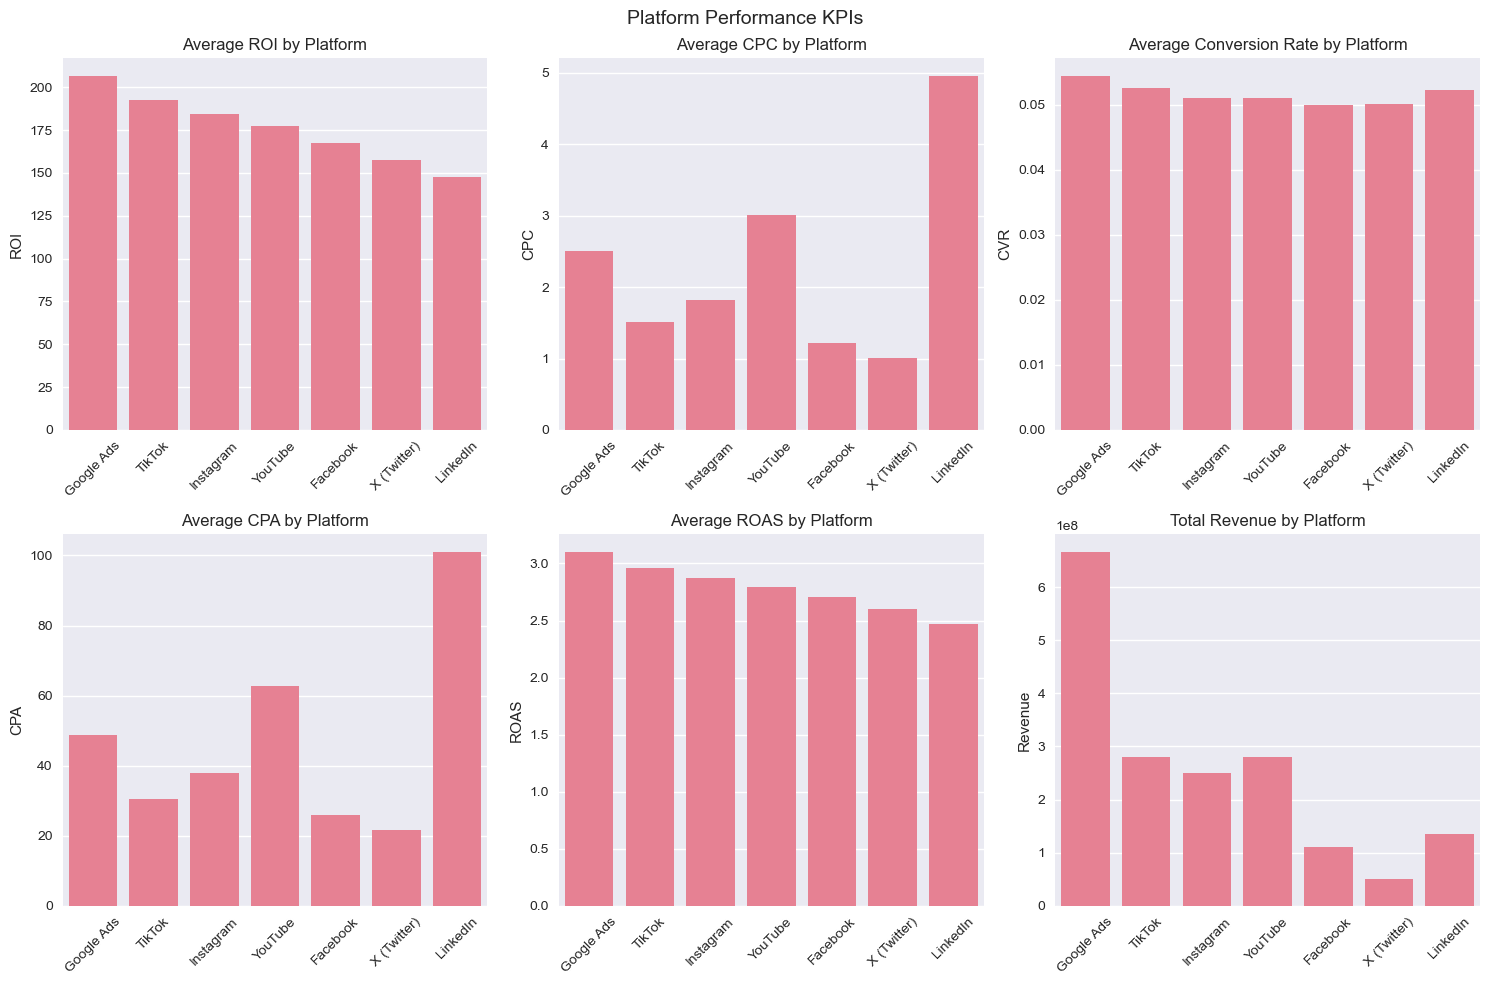

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Platform Performance KPIs', fontsize=14)

# ROI by Platform
sns.barplot(data=platform_kpi.reset_index(), x='PlatformName', y='ROI', ax=axes[0, 0])
axes[0, 0].set_title('Average ROI by Platform')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# CPC by Platform
sns.barplot(data=platform_kpi.reset_index(), x='PlatformName', y='CPC', ax=axes[0, 1])
axes[0, 1].set_title('Average CPC by Platform')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

# CVR by Platform
sns.barplot(data=platform_kpi.reset_index(), x='PlatformName', y='CVR', ax=axes[0, 2])
axes[0, 2].set_title('Average Conversion Rate by Platform')
axes[0, 2].set_xlabel('')
axes[0, 2].tick_params(axis='x', rotation=45)

# CPA by Platform
sns.barplot(data=platform_kpi.reset_index(), x='PlatformName', y='CPA', ax=axes[1, 0])
axes[1, 0].set_title('Average CPA by Platform')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)

# ROAS by Platform
sns.barplot(data=platform_kpi.reset_index(), x='PlatformName', y='ROAS', ax=axes[1, 1])
axes[1, 1].set_title('Average ROAS by Platform')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

# Revenue by Platform
sns.barplot(data=platform_kpi.reset_index(), x='PlatformName', y='Revenue', ax=axes[1, 2])
axes[1, 2].set_title('Total Revenue by Platform')
axes[1, 2].set_xlabel('')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/platform_kpi_analysis.png', dpi=300)
plt.show()

In [8]:
print("Platform Performance Insights")
print("-" * 40)

best_roi = platform_kpi['ROI'].idxmax()
worst_roi = platform_kpi['ROI'].idxmin()
best_cvr = platform_kpi['CVR'].idxmax()
lowest_cpc = platform_kpi['CPC'].idxmin()
lowest_cpa = platform_kpi['CPA'].idxmin()

print(f"Highest ROI: {best_roi} ({platform_kpi.loc[best_roi, 'ROI']:.1f}%)")
print(f"Lowest ROI: {worst_roi} ({platform_kpi.loc[worst_roi, 'ROI']:.1f}%)")
print(f"Highest CVR: {best_cvr} ({platform_kpi.loc[best_cvr, 'CVR']*100:.2f}%)")
print(f"Lowest CPC: {lowest_cpc} (${platform_kpi.loc[lowest_cpc, 'CPC']:.2f})")
print(f"Lowest CPA: {lowest_cpa} (${platform_kpi.loc[lowest_cpa, 'CPA']:.2f})")

Platform Performance Insights
----------------------------------------
Highest ROI: Google Ads (206.5%)
Lowest ROI: LinkedIn (147.8%)
Highest CVR: Google Ads (5.44%)
Lowest CPC: X (Twitter) ($1.01)
Lowest CPA: X (Twitter) ($21.62)


In [9]:
# Merge with campaign types
df_type = df.merge(campaign_types, on='CampaignTypeID')

# Aggregate by campaign type
type_kpi = df_type.groupby('CampaignType').agg({
    'CampaignID': 'count',
    'CTR': 'mean',
    'CPC': 'mean',
    'CPM': 'mean',
    'CVR': 'mean',
    'CPA': 'mean',
    'ROAS': 'mean',
    'ROI': 'mean',
    'Revenue': 'sum',
    'Cost': 'sum'
}).round(4)

type_kpi.columns = ['Campaigns', 'CTR', 'CPC', 'CPM', 'CVR', 'CPA', 'ROAS', 'ROI', 'Revenue', 'Cost']
type_kpi = type_kpi.sort_values('CVR', ascending=False)

print("Campaign Type KPI Summary")
print("-" * 40)
print(type_kpi.to_string())

Campaign Type KPI Summary
----------------------------------------
              Campaigns     CTR     CPC      CPM     CVR      CPA    ROAS       ROI       Revenue          Cost
CampaignType                                                                                                   
Search             1624  0.0231  2.2637  49.0412  0.0640  35.5042  2.7999  177.2246  3.676817e+08  1.282313e+08
Retargeting        1688  0.0209  2.2662  44.2955  0.0604  37.9287  2.8003  177.1681  3.264715e+08  1.144080e+08
Video              1686  0.0204  2.2910  43.5289  0.0566  40.8150  2.8513  181.0450  3.390901e+08  1.136021e+08
Social             1692  0.0185  2.3367  39.9065  0.0502  47.1380  2.7520  172.9900  2.999145e+08  1.082543e+08
Email              1682  0.0155  2.3177  33.3200  0.0428  55.4097  2.7291  172.3954  2.730074e+08  9.063025e+07
Display            1628  0.0110  2.2862  23.2529  0.0359  66.0718  2.7758  175.5690  1.678854e+08  5.971369e+07


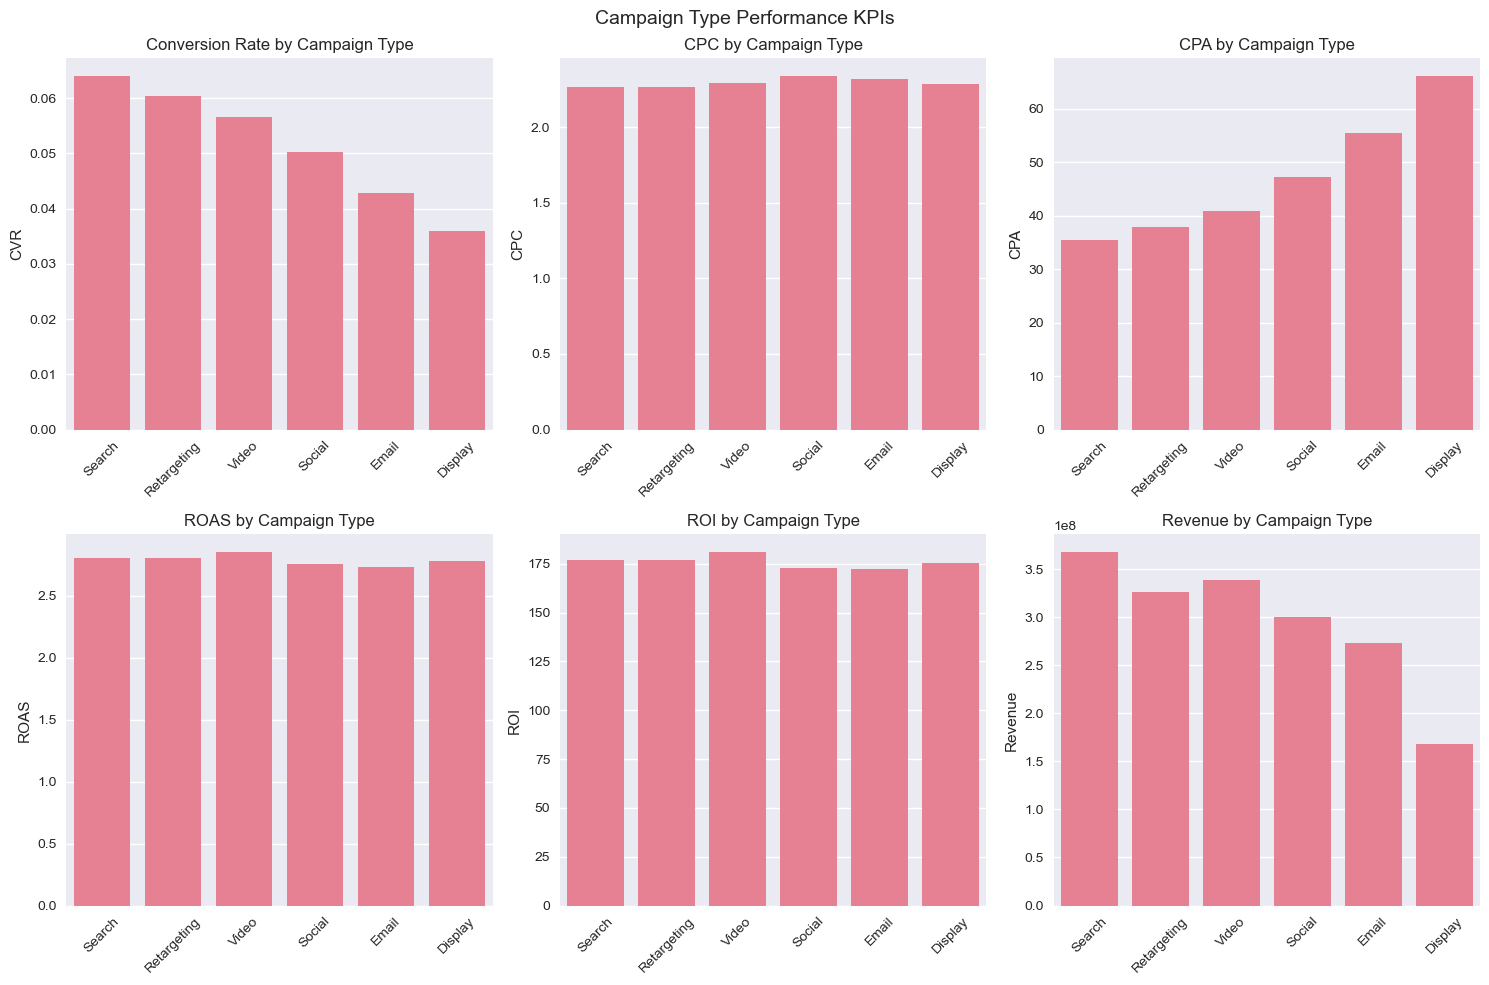

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Campaign Type Performance KPIs', fontsize=14)

# CVR by Type
sns.barplot(data=type_kpi.reset_index(), x='CampaignType', y='CVR', ax=axes[0, 0])
axes[0, 0].set_title('Conversion Rate by Campaign Type')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# CPC by Type
sns.barplot(data=type_kpi.reset_index(), x='CampaignType', y='CPC', ax=axes[0, 1])
axes[0, 1].set_title('CPC by Campaign Type')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

# CPA by Type
sns.barplot(data=type_kpi.reset_index(), x='CampaignType', y='CPA', ax=axes[0, 2])
axes[0, 2].set_title('CPA by Campaign Type')
axes[0, 2].set_xlabel('')
axes[0, 2].tick_params(axis='x', rotation=45)

# ROAS by Type
sns.barplot(data=type_kpi.reset_index(), x='CampaignType', y='ROAS', ax=axes[1, 0])
axes[1, 0].set_title('ROAS by Campaign Type')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)

# ROI by Type
sns.barplot(data=type_kpi.reset_index(), x='CampaignType', y='ROI', ax=axes[1, 1])
axes[1, 1].set_title('ROI by Campaign Type')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

# Revenue by Type
sns.barplot(data=type_kpi.reset_index(), x='CampaignType', y='Revenue', ax=axes[1, 2])
axes[1, 2].set_title('Revenue by Campaign Type')
axes[1, 2].set_xlabel('')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/type_kpi_analysis.png', dpi=300)
plt.show()

In [11]:
print("Campaign Type Performance Insights")
print("-" * 40)

best_cvr = type_kpi['CVR'].idxmax()
worst_cvr = type_kpi['CVR'].idxmin()
best_roas = type_kpi['ROAS'].idxmax()
lowest_cpa = type_kpi['CPA'].idxmin()

print(f"Highest CVR: {best_cvr} ({type_kpi.loc[best_cvr, 'CVR']*100:.2f}%)")
print(f"Lowest CVR: {worst_cvr} ({type_kpi.loc[worst_cvr, 'CVR']*100:.2f}%)")
print(f"Best ROAS: {best_roas} ({type_kpi.loc[best_roas, 'ROAS']:.2f}x)")
print(f"Lowest CPA: {lowest_cpa} (${type_kpi.loc[lowest_cpa, 'CPA']:.2f})")

Campaign Type Performance Insights
----------------------------------------
Highest CVR: Search (6.40%)
Lowest CVR: Display (3.59%)
Best ROAS: Video (2.85x)
Lowest CPA: Search ($35.50)


KPI Correlation Matrix
----------------------------------------
        CTR    CPC    CPM    CVR    CPA   ROAS    ROI
CTR   1.000 -0.260  0.713  0.423 -0.388  0.095  0.123
CPC  -0.260  1.000  0.418  0.045  0.866 -0.037 -0.044
CPM   0.713  0.418  1.000  0.369  0.206  0.066  0.086
CVR   0.423  0.045  0.369  1.000 -0.373  0.018  0.022
CPA  -0.388  0.866  0.206 -0.373  1.000 -0.040 -0.047
ROAS  0.095 -0.037  0.066  0.018 -0.040  1.000  0.960
ROI   0.123 -0.044  0.086  0.022 -0.047  0.960  1.000


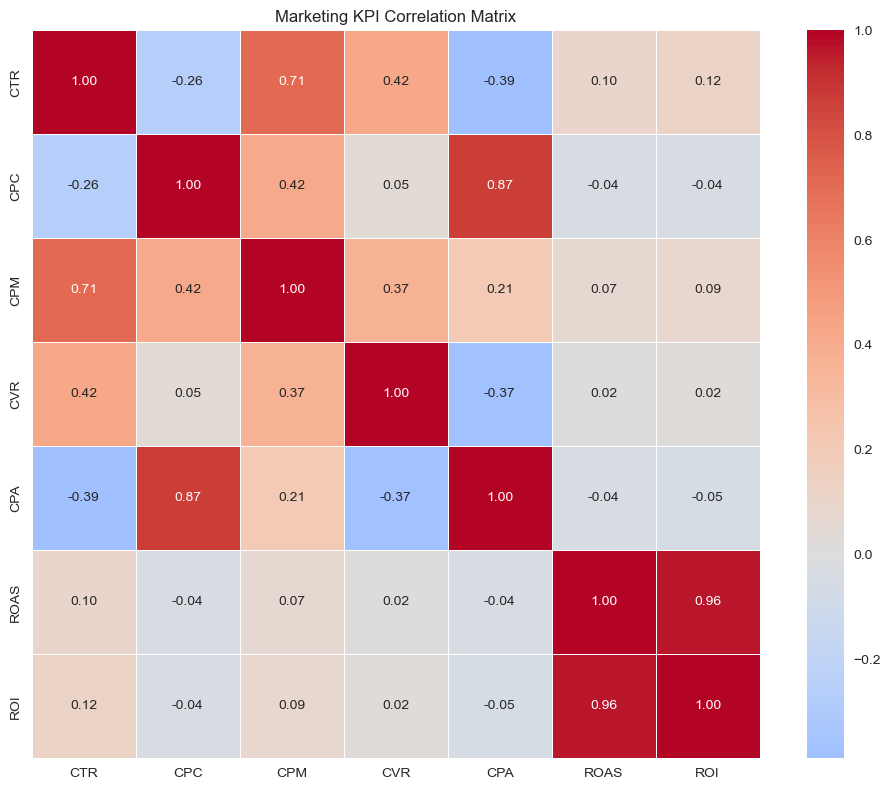

In [12]:
# Calculate correlation matrix
kpi_corr = df[['CTR', 'CPC', 'CPM', 'CVR', 'CPA', 'ROAS', 'ROI']].corr()

print("KPI Correlation Matrix")
print("-" * 40)
print(kpi_corr.round(3))

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(kpi_corr, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Marketing KPI Correlation Matrix')
plt.tight_layout()
plt.savefig('images/kpi_correlation_matrix.png', dpi=300)
plt.show()

In [14]:
print("Key Correlation Insights")
print("-" * 40)

# Find strongest correlations
corr_pairs = []
for i in range(len(kpi_corr.columns)):
    for j in range(i+1, len(kpi_corr.columns)):
        corr = kpi_corr.iloc[i, j]
        if abs(corr) > 0.3:
            corr_pairs.append((kpi_corr.columns[i], kpi_corr.columns[j], corr))

corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print("Strong Correlations (|r| > 0.3):")
for pair in corr_pairs[:6]:
    direction = "positive" if pair[2] > 0 else "negative"
    strength = "Strong" if abs(pair[2]) >= 0.7 else "Moderate" if abs(pair[2]) >= 0.5 else "Weak"
    print(f"  {pair[0]} ↔ {pair[1]}: {pair[2]:.3f} ({direction}, {strength})")

Key Correlation Insights
----------------------------------------
Strong Correlations (|r| > 0.3):
  ROAS ↔ ROI: 0.960 (positive, Strong)
  CPC ↔ CPA: 0.866 (positive, Strong)
  CTR ↔ CPM: 0.713 (positive, Strong)
  CTR ↔ CVR: 0.423 (positive, Weak)
  CPC ↔ CPM: 0.418 (positive, Weak)
  CTR ↔ CPA: -0.388 (negative, Weak)


In [15]:
print("Marketing KPI Analysis Summary")
print("-" * 40)

print("\nPlatform Rankings (by ROI):")
for i, (name, row) in enumerate(platform_kpi.iterrows(), 1):
    print(f"  {i}. {name}: {row['ROI']:.1f}%")

print("\nCampaign Type Rankings (by CVR):")
for i, (name, row) in enumerate(type_kpi.iterrows(), 1):
    print(f"  {i}. {name}: {row['CVR']*100:.2f}%")

print("\nKey Insights:")
print("  1. Google Ads has the highest ROI (206.5%)")
print("  2. Search campaigns have the highest CVR (6.40%)")
print("  3. LinkedIn has the lowest ROI (147.8%) and CTR (0.80%)")
print("  4. Display has the lowest CVR (3.59%) and highest CPA ($66.07)")

Marketing KPI Analysis Summary
----------------------------------------

Platform Rankings (by ROI):
  1. Google Ads: 206.5%
  2. TikTok: 192.5%
  3. Instagram: 184.4%
  4. YouTube: 177.6%
  5. Facebook: 167.2%
  6. X (Twitter): 157.6%
  7. LinkedIn: 147.8%

Campaign Type Rankings (by CVR):
  1. Search: 6.40%
  2. Retargeting: 6.04%
  3. Video: 5.66%
  4. Social: 5.02%
  5. Email: 4.28%
  6. Display: 3.59%

Key Insights:
  1. Google Ads has the highest ROI (206.5%)
  2. Search campaigns have the highest CVR (6.40%)
  3. LinkedIn has the lowest ROI (147.8%) and CTR (0.80%)
  4. Display has the lowest CVR (3.59%) and highest CPA ($66.07)
